# 프로젝트: SentencePiece를 활용한 네이버 영화리뷰 감성분석

## 프로젝트 목표

이번 프로젝트의 목표는 네이버 영화리뷰 감성분석 데이터(NSMC)에 SentencePiece 토크나이저를 적용하여 감성분석 모델을 학습하는 것이다.

기존 한국어 자연어처리에서는 KoNLPy의 Mecab, Okt 같은 형태소 분석기를 많이 사용한다. 이번 실습에서는 Subword 기반 토크나이저인 SentencePiece를 직접 학습하고, 이를 감성분석 모델에 적용한다.

이후 SentencePiece 기반 토큰화 결과와 KoNLPy 기반 토큰화 결과를 비교하여, 한국어 자연어처리에서 토크나이저 선택이 모델 성능과 단어사전 구성에 어떤 영향을 주는지 확인한다.

## 실험 순서

1. NSMC 데이터 다운로드
2. 데이터 불러오기 및 전처리
3. SentencePiece 학습용 corpus 생성
4. SentencePiece 모델 학습
5. SentencePiece 토큰화 함수 구현
6. 감성분석 모델 학습
7. KoNLPy 기반 토큰화 결과와 비교
8. 결과 분석 및 회고

### 한 줄 요약

SentencePiece 토크나이저를 직접 학습하고 네이버 영화리뷰 감성분석 모델에 적용한다.

In [1]:
!mkdir -p ~/work/sentencepiece_nsmc_project

In [2]:
!ls -lh ~/work

total 2.8M
drwxrwsr-x 5 jovyan users 4.0K Jun 16 02:13 data
drwxrwsr-x 5 jovyan users 4.0K Jun 10 03:37 data_augmentation
drwxrwsr-x 3 jovyan users 4.0K May 15 05:24 data_preprocess
drwxrwsr-x 5 jovyan users 4.0K Jun  2 00:43 human_segmentation
-rw-rw-r-- 1 jovyan users 2.8M Jun  5 03:32 human_segmentation_cat.ipynb
drwxrws--- 2 root   users  16K May 11 05:13 lost+found
-rw-r--r-- 1 jovyan users  618 Jun 17 00:24 nsmc_sentiment_sentencepiece.ipynb
drwxrwsr-x 2 jovyan users 4.0K May 18 06:01 pokemon
drwxrwsr-x 3 jovyan users 4.0K May 18 07:08 pokemon_eda
drwxrwsr-x 4 jovyan users 4.0K May 15 08:18 project
drwxr-sr-x 2 jovyan users 4.0K Jun 17 00:55 sentencepiece_nsmc_project
drwxrwsr-x 4 jovyan users 4.0K Jun 15 08:30 sentiment_classification
drwxr-sr-x 3 jovyan users 4.0K Jun 17 00:22 text_data_part1_summary
drwxrwsr-x 4 jovyan users 4.0K Jun 15 07:37 weat
drwxrwsr-x 3 jovyan users 4.0K Jun 16 00:03 word_embedding
drwxrwsr-x 4 jovyan users 4.0K Jun  2 08:06 workplace


In [15]:
!pip install sentencepiece
!pip install konlpy

In [4]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import sentencepiece as spm

from konlpy.tag import Okt

In [5]:
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

numpy: 2.2.6
pandas: 2.3.0
torch: 2.7.1+cu118
사용 장치: cuda


SentencePiece, pandas, PyTorch, KoNLPy를 준비하고 실행 환경을 확인한다.

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("seed fixed:", SEED)

seed fixed: 42


랜덤 시드 고정하기: 시드를 고정하면 실험 결과를 비교하기 쉬워진다.

장점
실험 재현성이 좋아진다.
같은 조건에서 결과 비교가 쉬워진다.

단점
완전히 동일한 결과가 항상 보장되는 것은 아니다.
GPU 연산에서는 약간의 차이가 생길 수 있다.

In [7]:
!mkdir -p ~/work/sentencepiece_nsmc_project/data

!wget -O ~/work/sentencepiece_nsmc_project/data/ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget -O ~/work/sentencepiece_nsmc_project/data/ratings_test.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

--2026-06-17 00:56:55--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘/home/jovyan/work/sentencepiece_nsmc_project/data/ratings_train.txt’

/home/jovyan/work/s 100%[===================>]  13.95M  44.3MB/s    in 0.3s    

2026-06-17 00:56:56 (44.3 MB/s) - ‘/home/jovyan/work/sentencepiece_nsmc_project/data/ratings_train.txt’ saved [14628807/14628807]

--2026-06-17 00:56:57--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443...

In [8]:
!ls -lh ~/work/sentencepiece_nsmc_project/data

total 19M
-rw-r--r-- 1 jovyan users 4.7M Jun 17 00:56 ratings_test.txt
-rw-r--r-- 1 jovyan users  14M Jun 17 00:56 ratings_train.txt


네이버 영화리뷰 감성분석 train/test 데이터를 프로젝트 폴더에 다운로드한다.

장점
공식 NSMC 데이터를 바로 사용할 수 있다.
train/test가 이미 나뉘어 있어 실험하기 편하다.

단점
인터넷 연결이 필요하다.
다운로드 경로를 잘못 지정하면 파일을 찾기 어렵다.

In [9]:
train_path = os.path.expanduser("~/work/sentencepiece_nsmc_project/data/ratings_train.txt")
test_path = os.path.expanduser("~/work/sentencepiece_nsmc_project/data/ratings_test.txt")

train_data = pd.read_table(train_path)
test_data = pd.read_table(test_path)

print("train 데이터 크기:", train_data.shape)
print("test 데이터 크기:", test_data.shape)

train_data.head()

train 데이터 크기: (150000, 3)
test 데이터 크기: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [10]:
train_data.sample(10, random_state=42)

,id,document,label
59770,8932939,수OO만에 다시보네여,1
21362,3681731,일방적인 영화다. 관객 좀 고려해주시길,0
127324,9847174,세상을 초월하는 한 사람의 선한 마음,1
140509,8506899,멍하다.. 여러생각이 겹치는데 오랜만에 영화 보고 이런 느낌 느껴본다,1
144297,9991656,"우와 별 반개도 아까운판에 밑에 CJ 알바생들 쩐다.. 전부 만점이야 ㅎㅎㅎ..,....",0
96370,6093387,지금도 가끔 다시 본다,1
49742,10155375,재미있는 추리 영화인줄 알고 봤는데 아니네요. 스토리도 그닥 와닿지 않고 다른 분들...,0
47389,6265202,일본영화를 거의 처음 본 건데 정말 재밌게 봤습니다~! 강추 두둥!!,1
58378,5716851,결말이참 맘에든다. 넘 사랑스럽지만 이루어질 수 없는 로망스ㅜㅜ,1
69047,9891398,엇갈린 사랑 해보신 분들께 추천 합니다.,1


다운로드한 NSMC 데이터를 pandas DataFrame으로 불러온다.

장점
데이터 구조를 바로 확인할 수 있다.
document, label 컬럼이 있는지 확인할 수 있다.

단점
파일 경로가 틀리면 FileNotFoundError가 난다.
커널을 재시작하면 다시 실행해야 한다.

In [11]:
print("train 결측치:")
print(train_data.isnull().sum())

print("\ntest 결측치:")
print(test_data.isnull().sum())

train 결측치:
id          0
document    5
label       0
dtype: int64

test 결측치:
id          0
document    3
label       0
dtype: int64


토큰화 오류를 막기 위해 비어 있는 리뷰가 있는지 확인한다.

In [12]:
train_data = train_data.dropna()
test_data = test_data.dropna()

print("결측치 제거 후 train:", train_data.shape)
print("결측치 제거 후 test:", test_data.shape)

print("train 결측치 재확인:")
print(train_data.isnull().sum())

print("\ntest 결측치 재확인:")
print(test_data.isnull().sum())

결측치 제거 후 train: (149995, 3)
결측치 제거 후 test: (49997, 3)
train 결측치 재확인:
id          0
document    0
label       0
dtype: int64

test 결측치 재확인:
id          0
document    0
label       0
dtype: int64


문장이 비어 있는 행은 제거한다.

장점
비어 있는 문장으로 인한 오류를 막을 수 있다.
토큰화와 모델 학습이 안정적이 된다.

단점
데이터 수가 조금 줄어든다.

In [13]:
print("train 전체 중복 개수:", train_data.duplicated().sum())
print("test 전체 중복 개수:", test_data.duplicated().sum())

print("train document 중복 개수:", train_data["document"].duplicated().sum())
print("test document 중복 개수:", test_data["document"].duplicated().sum())

train 전체 중복 개수: 0
test 전체 중복 개수: 0
train document 중복 개수: 3813
test document 중복 개수: 840


In [14]:
train_data = train_data.drop_duplicates(subset=["document"])
test_data = test_data.drop_duplicates(subset=["document"])

print("중복 제거 후 train:", train_data.shape)
print("중복 제거 후 test:", test_data.shape)

print("중복 제거 후 train document 중복 개수:", train_data["document"].duplicated().sum())
print("중복 제거 후 test document 중복 개수:", test_data["document"].duplicated().sum())

중복 제거 후 train: (146182, 3)
중복 제거 후 test: (49157, 3)
중복 제거 후 train document 중복 개수: 0
중복 제거 후 test document 중복 개수: 0


결측치와 중복을 제거해 모델 학습용 데이터를 정리한다.

장점
데이터 품질이 좋아진다.
같은 문장을 반복 학습하는 문제를 줄인다.

단점
데이터 수가 줄어든다.
중복 제거 기준을 잘못 잡으면 필요한 데이터도 제거될 수 있다.

In [16]:
print("train label 분포:")
print(train_data["label"].value_counts())

print("\ntrain label 비율:")
print(train_data["label"].value_counts(normalize=True))

print("\ntest label 분포:")
print(test_data["label"].value_counts())

print("\ntest label 비율:")
print(test_data["label"].value_counts(normalize=True))

train label 분포:
label
0    73342
1    72840
Name: count, dtype: int64

train label 비율:
label
0    0.501717
1    0.498283
Name: proportion, dtype: float64

test label 분포:
label
1    24711
0    24446
Name: count, dtype: int64

test label 비율:
label
1    0.502695
0    0.497305
Name: proportion, dtype: float64


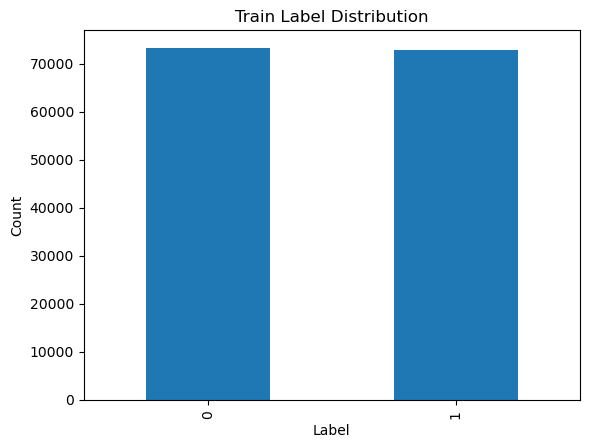

In [17]:
train_data["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Train Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

긍정과 부정 리뷰가 균형적으로 들어 있는지 확인한다.

장점
데이터 불균형 여부를 확인할 수 있다.
모델 성능 해석에 도움이 된다.

단점
라벨이 균형적이어도 문장 품질 문제는 따로 확인해야 한다.

In [18]:
corpus_file = "nsmc_spm_corpus.txt"

with open(corpus_file, "w", encoding="utf-8") as f:
    for sentence in train_data["document"]:
        f.write(str(sentence) + "\n")

print("SentencePiece 학습용 corpus 저장 완료:", corpus_file)

SentencePiece 학습용 corpus 저장 완료: nsmc_spm_corpus.txt


In [19]:
!head -n 5 nsmc_spm_corpus.txt

아 더빙.. 진짜 짜증나네요 목소리
흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
너무재밓었다그래서보는것을추천한다
교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다


SentencePiece 학습을 위해 train 리뷰 문장만 모은 corpus 파일을 만든다.

장점
NSMC 데이터에 맞는 토크나이저를 만들 수 있다.
리뷰 특유의 표현을 사전에 반영할 수 있다.

단점
오탈자나 비속어도 그대로 학습될 수 있다.
전처리 수준에 따라 토큰화 품질이 달라진다.

## Step 12. SentencePiece 모델 학습

앞에서 만든 `nsmc_spm_corpus.txt` 파일을 이용하여 SentencePiece 토크나이저를 학습한다.

SentencePiece는 문장을 단어 단위가 아니라 더 작은 subword 단위로 나누는 토크나이저이다.  
이번 실습에서는 NSMC 영화리뷰 데이터에 맞는 SentencePiece 단어사전을 직접 만든다.

기본 실험에서는 `model_type='unigram'`, `vocab_size=8000`으로 설정한다.

### 장점
NSMC 데이터에 맞는 토크나이저를 직접 만들 수 있다.  
처음 보는 단어도 subword 조각으로 처리할 수 있어 OOV 문제를 줄일 수 있다.

### 단점
토큰이 형태소처럼 사람이 직관적으로 이해하기 쉬운 단위로 나뉘지는 않을 수 있다.  
vocab_size와 model_type 설정에 따라 결과가 달라질 수 있다.

### 한 줄 요약
SentencePiece 모델 학습은 NSMC 리뷰 문장을 subword 단위로 나누기 위한 전용 토크나이저를 만드는 과정이다.

In [20]:
import sentencepiece as spm

vocab_size = 8000
model_type = "unigram"
model_prefix = f"nsmc_spm_{model_type}_{vocab_size}"

spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    model_type=model_type,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

print("SentencePiece 모델 학습 완료")
print("model prefix:", model_prefix)

SentencePiece 모델 학습 완료
model prefix: nsmc_spm_unigram_8000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_spm_corpus.txt
  input_format: 
  model_prefix: nsmc_spm_unigram_8000
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential

NSMC 리뷰 문장으로 SentencePiece 토크나이저를 직접 학습한다.

## Step 13. SentencePiece 학습 결과 파일 확인

SentencePiece 모델 학습이 완료되면 `.model` 파일과 `.vocab` 파일이 생성된다.

- `.model`: 실제 토크나이저 모델 파일
- `.vocab`: 학습된 subword 단어사전 파일

이 두 파일이 정상적으로 생성되어야 이후 문장을 숫자 ID로 인코딩하고 다시 문장으로 디코딩할 수 있다.

### 한 줄 요약
SentencePiece 학습 결과로 생성된 model 파일과 vocab 파일을 확인한다.

In [21]:
!ls -lh nsmc_spm_*

-rw-r--r-- 1 jovyan users  13M Jun 17 01:45 nsmc_spm_corpus.txt
-rw-r--r-- 1 jovyan users 369K Jun 17 01:48 nsmc_spm_unigram_8000.model
-rw-r--r-- 1 jovyan users 142K Jun 17 01:48 nsmc_spm_unigram_8000.vocab


In [22]:
!ls -lh nsmc_spm_*

-rw-r--r-- 1 jovyan users  13M Jun 17 01:45 nsmc_spm_corpus.txt
-rw-r--r-- 1 jovyan users 369K Jun 17 01:48 nsmc_spm_unigram_8000.model
-rw-r--r-- 1 jovyan users 142K Jun 17 01:48 nsmc_spm_unigram_8000.vocab


In [23]:
!head -n 20 nsmc_spm_unigram_8000.vocab

<pad>	0
<unk>	0
<s>	0
</s>	0
▁	-3.11756
.	-3.48884
이	-4.33307
..	-4.39468
▁영화	-4.58347
...	-4.64282
가	-4.66051
의	-4.66562
도	-4.72804
는	-4.7953
,	-4.927
을	-4.95731
에	-5.00933
고	-5.08279
다	-5.14894
은	-5.17397


모델 학습이 끝났으니 .model과 .vocab 파일이 제대로 생성됐는지 확인한다.

장점
SentencePiece 모델이 실제 파일로 저장되었는지 확인할 수 있어. 이후 같은 모델을 다시 불러와 재사용할 수 있다.

단점
.vocab만 보고는 토크나이저 품질을 완전히 판단하기 어렵다. 실제 문장에 적용해서 확인해야 한.

## Step 14. SentencePiece 인코딩/디코딩 테스트

학습된 SentencePiece 모델을 불러와 문장을 subword 조각과 숫자 ID로 변환한다.

- `EncodeAsPieces()`: 문장을 subword 조각으로 변환
- `EncodeAsIds()`: 문장을 숫자 ID로 변환
- `DecodeIds()`: 숫자 ID를 다시 문장으로 복원

이 과정을 통해 SentencePiece 토크나이저가 정상적으로 작동하는지 확인한다.

### 한 줄 요약
학습된 SentencePiece 모델로 문장을 조각내고, 숫자로 바꾸고, 다시 복원해본다.

In [24]:
import sentencepiece as spm

sp = spm.SentencePieceProcessor()
sp.Load("nsmc_spm_unigram_8000.model")

sample = "아버지가방에들어가신다."

print("원문:", sample)
print("Pieces:", sp.EncodeAsPieces(sample))
print("IDs:", sp.EncodeAsIds(sample))
print("복원:", sp.DecodeIds(sp.EncodeAsIds(sample)))

원문: 아버지가방에들어가신다.
Pieces: ['▁아버지', '가', '방', '에', '들어', '가', '신', '다', '.']
IDs: [1406, 10, 397, 16, 1286, 10, 119, 18, 5]
복원: 아버지가방에들어가신다.


In [25]:
sample_review = train_data["document"].iloc[0]

print("원문:", sample_review)
print("Pieces:", sp.EncodeAsPieces(sample_review))
print("IDs:", sp.EncodeAsIds(sample_review))
print("복원:", sp.DecodeIds(sp.EncodeAsIds(sample_review)))

원문: 아 더빙.. 진짜 짜증나네요 목소리
Pieces: ['▁아', '▁더빙', '..', '▁진짜', '▁짜증나', '네요', '▁목소리']
IDs: [67, 882, 7, 33, 2198, 65, 1429]
복원: 아 더빙.. 진짜 짜증나네요 목소리


SentencePiece 모델이 문장을 subword 조각과 숫자 ID로 잘 바꾸는지 확인한다.

| 확인 항목  | 정상 기준                      |
| ------ | -------------------------- |
| Pieces | 문장이 여러 subword 조각으로 나뉘어야 함 |
| IDs    | 숫자 리스트가 나와야 함              |
| 복원     | 원문과 거의 비슷하게 복원되어야 함        |

장점
문장이 실제로 어떻게 잘리는지 눈으로 확인할 수 있다. 모델 입력으로 사용할 숫자 ID가 잘 만들어지는지도 확인할 수 있다.

단점
SentencePiece 조각은 형태소 분석 결과처럼 직관적이지 않을 수 있다. 예를 들어 _아, 버지, 가방처럼 예상과 다르게 잘릴 수 있다.

장점

문장이 실제로 어떻게 잘리는지 눈으로 확인할 수 있어. 모델 입력으로 사용할 숫자 ID가 잘 만들어지는지도 확인할 수 있어.

단점

SentencePiece 조각은 형태소 분석 결과처럼 직관적이지 않을 수 있어. 예를 들어 _아, 버지, 가방처럼 예상과 다르게 잘릴 수 있어.

In [26]:
import torch
from torch.nn.utils.rnn import pad_sequence

def sp_tokenize(sp, corpus, vocab_path):
    tensor = []

    for sen in corpus:
        ids = sp.EncodeAsIds(str(sen))
        tensor.append(torch.tensor(ids, dtype=torch.long))

    with open(vocab_path, "r", encoding="utf-8") as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]
        word_index[word] = idx
        index_word[idx] = word

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

In [27]:
vocab_path = "nsmc_spm_unigram_8000.vocab"

sample_tensor, sp_word_index, sp_index_word = sp_tokenize(
    sp,
    train_data["document"].iloc[:5],
    vocab_path
)

print("sample tensor:")
print(sample_tensor)

print("sample tensor shape:", sample_tensor.shape)
print("vocab size:", len(sp_word_index))

sample tensor:
tensor([[  67,  882,    7,   33, 2198,   65, 1429,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [1796,    9, 4954,  159, 1418,   32,  251,   63,  171,  408,  371, 1332,
         6813,  830,  410,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [  25,  390, 7775,  369, 3924,  105, 6021, 2081,  302,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [1865,   12,  198,  236, 6626,    4,    7, 4371, 1301,  123,    7,  691,
          297,   99,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [2416, 2410, 2069,  167,   11,    4, 1444,  319, 2398,  509, 2687, 1807,
            8,   26, 5703,   47, 6324, 2475, 1242, 2945, 2435, 6295,    

sp_tokenize() 함수로 SentencePiece 토큰화 결과를 PyTorch Tensor로 바꾼다.

장점
문장 리스트를 한 번에 Tensor로 만들 수 있다. 이후 PyTorch 모델 입력으로 바로 연결할 수 있다.

단점
전체 데이터를 한 번에 처리하면 가장 긴 문장 기준으로 padding되어 메모리를 많이 쓸 수 있다. 그래서 실제 모델 학습에서는 MAX_LEN을 적용한 Dataset 방식을 추천한다.

## Step 16. MAX_LEN 적용 인코딩 함수 만들기

앞에서 만든 `sp_tokenize()` 함수는 문장들을 한 번에 Tensor로 변환할 수 있지만, 전체 데이터를 한 번에 처리하면 가장 긴 문장 기준으로 padding되어 메모리를 많이 사용할 수 있다.

따라서 실제 모델 학습에서는 각 문장을 SentencePiece ID로 바꾼 뒤, 길이가 너무 길면 자르고 짧으면 0으로 padding하여 고정 길이 Tensor로 만든다.

이번 실습에서는 `MAX_LEN=80`으로 설정한다.

### 장점
문장 길이가 고정되어 batch 학습이 쉬워진다.  
메모리 사용량을 조절할 수 있다.

### 단점
너무 긴 문장은 뒷부분 정보가 잘릴 수 있다.  
MAX_LEN 설정에 따라 성능이 달라질 수 있다.

### 한 줄 요약
문장 길이를 고정하여 모델 학습에 사용할 수 있는 안정적인 입력 Tensor를 만든다.

In [28]:
MAX_LEN = 80

def encode_sentence(sp, sentence, max_len=MAX_LEN):
    ids = sp.EncodeAsIds(str(sentence))
    
    # 길면 자르기
    ids = ids[:max_len]
    
    # 짧으면 0으로 padding
    if len(ids) < max_len:
        ids = ids + [0] * (max_len - len(ids))
        
    return torch.tensor(ids, dtype=torch.long)

In [30]:
sample_encoded = encode_sentence(sp, train_data["document"].iloc[0])

print(sample_encoded)
print("encoded shape:", sample_encoded.shape)

tensor([  67,  882,    7,   33, 2198,   65, 1429,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
encoded shape: torch.Size([80])


각 리뷰 문장을 길이 80짜리 숫자 Tensor로 바꾼다.

## Step 17. PyTorch Dataset 만들기

PyTorch 모델은 데이터를 하나씩 직접 다루기보다 Dataset과 DataLoader를 통해 batch 단위로 학습한다.

`NSMCDataset` 클래스는 리뷰 문장을 SentencePiece ID Tensor로 변환하고, 해당 리뷰의 감성 라벨을 함께 반환한다.

- 입력 `x`: SentencePiece로 인코딩된 리뷰 문장 Tensor
- 정답 `y`: 감성 라벨, 0은 부정, 1은 긍정

### 한 줄 요약
Dataset은 리뷰 문장과 정답 라벨을 모델이 학습할 수 있는 형태로 꺼내주는 역할을 한다.

In [31]:
from torch.utils.data import Dataset, DataLoader

class NSMCDataset(Dataset):
    def __init__(self, dataframe, sp, max_len=MAX_LEN):
        self.sentences = dataframe["document"].tolist()
        self.labels = dataframe["label"].tolist()
        self.sp = sp
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        x = encode_sentence(self.sp, self.sentences[idx], self.max_len)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [32]:
sample_dataset = NSMCDataset(train_data.iloc[:5], sp, MAX_LEN)

x, y = sample_dataset[0]

print("x:", x)
print("x shape:", x.shape)
print("y:", y)

x: tensor([  67,  882,    7,   33, 2198,   65, 1429,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
x shape: torch.Size([80])
y: tensor(0)


Dataset은 리뷰 하나를 입력 Tensor와 정답 라벨로 바꿔주는 구조다.

장점
문장과 라벨을 깔끔하게 묶을 수 있다.
PyTorch 학습 구조에 바로 연결된다.
전체 데이터를 한 번에 Tensor로 만들 필요가 없다.

단점
Dataset 클래스를 직접 작성해야 한다.
매번 문장을 인코딩하므로 속도가 조금 느릴 수 있다.

## Step 18. DataLoader 만들기

DataLoader는 Dataset에서 데이터를 가져와 batch 단위로 묶어준다.  
모델은 한 문장씩 학습하는 것이 아니라 여러 문장을 한 묶음으로 받아 학습한다.

처음 실험에서는 전체 데이터를 사용하기보다 일부 샘플 데이터로 빠르게 동작을 확인한다.

### 한 줄 요약
DataLoader는 리뷰 데이터를 batch 단위로 묶어 모델 학습에 전달한다.

In [33]:
# 빠른 실험을 위해 일부 데이터만 사용
train_sample = train_data.sample(30000, random_state=42)
test_sample = test_data.sample(10000, random_state=42)

print("train sample:", train_sample.shape)
print("test sample:", test_sample.shape)

train sample: (30000, 3)
test sample: (10000, 3)


In [34]:
BATCH_SIZE = 64

train_dataset = NSMCDataset(train_sample, sp, MAX_LEN)
test_dataset = NSMCDataset(test_sample, sp, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [35]:
x_batch, y_batch = next(iter(train_loader))

print("x batch shape:", x_batch.shape)
print("y batch shape:", y_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)

x batch shape: torch.Size([64, 80])
y batch shape: torch.Size([64])
x dtype: torch.int64
y dtype: torch.int64


DataLoader는 문장 Tensor와 라벨을 batch로 묶어 모델에 전달한다.

장점
batch 단위 학습이 가능하다.
shuffle로 학습 편향을 줄일 수 있다.
모델 학습 코드가 간단해진다.

단점
batch size가 크면 메모리를 많이 쓴다.
CPU 환경에서는 학습 속도가 느릴 수 있다.

## Step 19. LSTM 감성분석 모델 정의

이번 프로젝트에서는 SentencePiece로 인코딩한 리뷰 문장을 LSTM 기반 감성분석 모델에 입력한다.

모델 구조는 다음과 같다.

1. Embedding Layer: 토큰 ID를 벡터로 변환
2. BiLSTM Layer: 문장의 앞뒤 문맥 학습
3. Dropout: 과적합 방지
4. Fully Connected Layer: 긍정/부정 2개 클래스로 분류

### 한 줄 요약
SentencePiece ID를 임베딩한 뒤 LSTM으로 문맥을 학습하여 감성을 분류한다.

In [36]:
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, pad_idx=0):
        super().__init__()
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        
        # bidirectional LSTM의 마지막 forward/backward hidden 결합
        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        hidden_cat = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        out = self.dropout(hidden_cat)
        out = self.fc(out)
        
        return out

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

VOCAB_SIZE = len(sp_word_index)   # 8000
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 2

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=0
).to(device)

print(model)

사용 장치: cuda
SentimentLSTM(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [38]:
x_batch = x_batch.to(device)

with torch.no_grad():
    logits = model(x_batch)

print("logits shape:", logits.shape)
print(logits[:5])

logits shape: torch.Size([64, 2])
tensor([[ 0.0170, -0.0785],
        [ 0.1033, -0.0271],
        [-0.0487,  0.1029],
        [-0.0041,  0.0337],
        [ 0.1137, -0.0087]], device='cuda:0')


LSTM 모델은 SentencePiece 토큰 ID를 받아 긍정/부정을 예측한다.

장점
문장 순서를 반영할 수 있다.
양방향 LSTM으로 앞뒤 문맥을 모두 볼 수 있다.
감성분석 기본 모델로 적절하다.

단점
CNN보다 학습이 느릴 수 있다.
Transformer 계열보다 성능이 낮을 수 있다.
긴 문장에서는 정보 손실이 있을 수 있다.

## Step 20. 학습 함수와 평가 함수 만들기

모델 학습은 train 데이터로 손실을 줄이며 가중치를 업데이트하는 과정이다.  
평가는 test 데이터에서 모델이 얼마나 잘 맞히는지 확인하는 과정이다.

이번 실습에서는 CrossEntropyLoss와 Adam optimizer를 사용한다.

### 한 줄 요약
학습 함수는 모델을 훈련시키고, 평가 함수는 정확도를 측정한다.

In [40]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    
    total_loss = 0
    total_correct = 0
    total_count = 0
    
    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        
        logits = model(x)
        loss = criterion(logits, y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y).sum().item()
        total_count += y.size(0)
        
    avg_loss = total_loss / total_count
    accuracy = total_correct / total_count
    
    return avg_loss, accuracy

In [41]:
def evaluate(model, dataloader, criterion):
    model.eval()
    
    total_loss = 0
    total_correct = 0
    total_count = 0
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            
            logits = model(x)
            loss = criterion(logits, y)
            
            total_loss += loss.item() * x.size(0)
            
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == y).sum().item()
            total_count += y.size(0)
            
    avg_loss = total_loss / total_count
    accuracy = total_correct / total_count
    
    return avg_loss, accuracy

학습 함수는 모델을 업데이트하고, 평가 함수는 모델 성능을 확인한다.

## Step 21. 모델 학습 실행

SentencePiece로 인코딩한 NSMC 리뷰 데이터를 사용하여 LSTM 감성분석 모델을 학습한다.

처음에는 빠른 확인을 위해 3 epoch만 학습한다.  
학습 결과로 train accuracy와 test accuracy를 함께 확인한다.

### 한 줄 요약
SentencePiece 기반 감성분석 모델을 실제로 학습하고 정확도를 확인한다.

In [43]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 3

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
    print("-" * 50)

Epoch 1/3
Train Loss: 0.6088 | Train Acc: 0.6562
Test  Loss: 0.5620 | Test  Acc: 0.7079
--------------------------------------------------
Epoch 2/3
Train Loss: 0.4361 | Train Acc: 0.7990
Test  Loss: 0.4529 | Test  Acc: 0.7916
--------------------------------------------------
Epoch 3/3
Train Loss: 0.3301 | Train Acc: 0.8589
Test  Loss: 0.4301 | Test  Acc: 0.8065
--------------------------------------------------


3 epoch 학습을 돌려 SentencePiece 기반 감성분석 모델의 기본 성능을 확인한다.

| 결과                         | 의미                 |
| -------------------------- | ------------------ |
| Train Acc 상승               | 모델이 학습 데이터를 배우고 있음 |
| Test Acc 상승                | 일반화 성능이 좋아지고 있음    |
| Train Acc만 상승, Test Acc 정체 | 과적합 가능성            |
| 둘 다 0.5 근처                 | 학습이 잘 안 됨          |
| Test Acc 0.75 이상           | 기본 실험으로는 괜찮은 흐름    |
| Test Acc 0.80 이상           | 꽤 좋은 결과            |

장점
SentencePiece 기반 모델 성능을 직접 확인할 수 있다.
이후 Okt/Mecab 기반 결과와 비교할 수 있다.

단점
CPU에서는 시간이 오래 걸릴 수 있다.
샘플 데이터만 쓰면 최종 성능이 낮을 수 있다.
epoch, max_len, vocab_size에 따라 결과가 달라질 수 있다.

## Step 22. 학습 결과 시각화

3 epoch 동안의 train/test accuracy와 loss 변화를 그래프로 확인한다.

학습 정확도와 테스트 정확도가 함께 상승하면 모델이 정상적으로 학습되고 있다고 볼 수 있다.  
반대로 train accuracy만 상승하고 test accuracy가 정체되거나 하락하면 과적합 가능성을 의심할 수 있다.

### 한 줄 요약
학습 결과를 그래프로 확인하여 모델이 잘 학습되었는지 시각적으로 점검한다.

### 장점
숫자만 볼 때보다 학습 흐름을 직관적으로 이해할 수 있다.  
과적합 여부를 확인하는 데 도움이 된다.

### 단점
epoch 수가 3개로 적기 때문에 그래프 해석에는 한계가 있다.

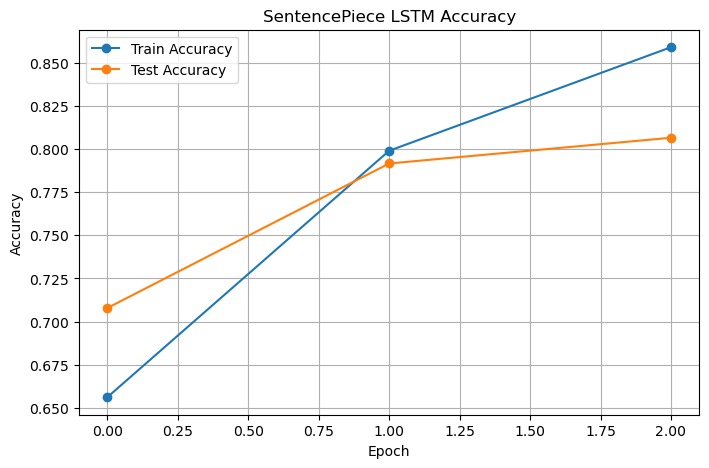

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history["test_acc"], marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SentencePiece LSTM Accuracy")
plt.legend()
plt.grid(True)
plt.show()

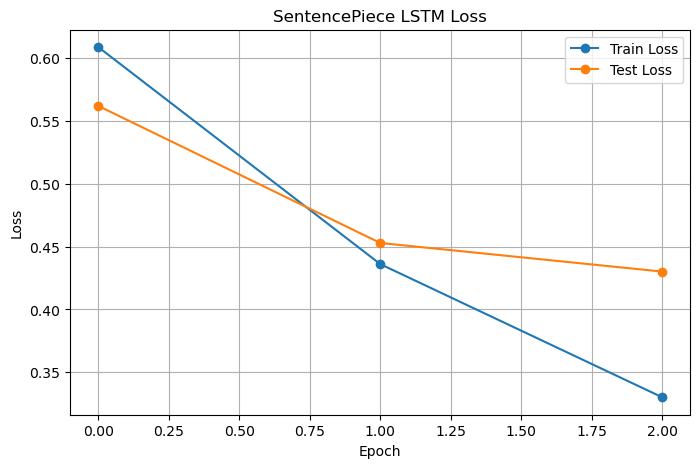

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["test_loss"], marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SentencePiece LSTM Loss")
plt.legend()
plt.grid(True)
plt.show()

## Step 23. SentencePiece 모델 학습 결과 정리

SentencePiece unigram 방식, vocab_size=8000, MAX_LEN=80 설정으로 LSTM 감성분석 모델을 학습하였다.

3 epoch 학습 결과, test accuracy는 약 0.8065까지 상승하였다.

### 한 줄 요약
SentencePiece 기반 LSTM 모델은 3 epoch 학습 후 약 80% 수준의 테스트 정확도를 보였다.

### 장점
짧은 epoch만으로도 감성분석 기본 성능을 확인할 수 있었다.  
SentencePiece 토크나이저가 실제 분류 모델 입력으로 정상 작동함을 확인하였다.

### 단점
샘플 데이터로 학습했기 때문에 전체 데이터 학습 결과와는 차이가 있을 수 있다.  
epoch 수, MAX_LEN, vocab_size에 따라 성능이 달라질 수 있다.

In [46]:
result_df = pd.DataFrame({
    "epoch": [1, 2, 3],
    "train_loss": history["train_loss"],
    "train_acc": history["train_acc"],
    "test_loss": history["test_loss"],
    "test_acc": history["test_acc"]
})

result_df

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.608834,0.656233,0.562015,0.7079
1,2,0.436084,0.798967,0.452912,0.7916
2,3,0.330061,0.858933,0.430137,0.8065


## Step 24. 직접 작성한 문장으로 감성 예측하기

학습된 모델에 직접 작성한 영화 리뷰 문장을 입력하여 긍정/부정 예측 결과를 확인한다.

SentencePiece로 문장을 인코딩한 뒤 모델에 입력하고, 출력값이 더 큰 클래스를 예측 라벨로 사용한다.

### 한 줄 요약
학습된 모델이 새로운 리뷰 문장을 긍정 또는 부정으로 분류하는지 확인한다.

### 장점
모델이 실제 문장에 어떻게 반응하는지 직관적으로 확인할 수 있다.  
정확도 수치 외에 모델 사용 흐름을 보여줄 수 있다.

### 단점
몇 개 문장만으로 모델 전체 성능을 판단할 수는 없다.  
짧은 문장이나 반어법 문장은 잘못 예측할 수 있다.

In [48]:
def predict_sentiment(model, sp, sentence, max_len=MAX_LEN):
    model.eval()
    
    x = encode_sentence(sp, sentence, max_len).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    
    label_text = "긍정" if pred == 1 else "부정"
    
    return label_text, probs.cpu().numpy()[0]

In [49]:
test_sentences = [
    "정말 재미있고 감동적인 영화였다.",
    "시간이 너무 아까웠고 지루했다.",
    "배우 연기는 좋았지만 스토리는 별로였다.",
    "다시 보고 싶을 정도로 훌륭한 작품이다.",
    "최악이었다. 추천하고 싶지 않다."
]

for sentence in test_sentences:
    label, probs = predict_sentiment(model, sp, sentence)
    print("문장:", sentence)
    print("예측:", label)
    print("확률:", probs)
    print("-" * 50)

문장: 정말 재미있고 감동적인 영화였다.
예측: 긍정
확률: [0.03337451 0.9666255 ]
--------------------------------------------------
문장: 시간이 너무 아까웠고 지루했다.
예측: 부정
확률: [0.99734133 0.00265868]
--------------------------------------------------
문장: 배우 연기는 좋았지만 스토리는 별로였다.
예측: 부정
확률: [0.77013206 0.22986792]
--------------------------------------------------
문장: 다시 보고 싶을 정도로 훌륭한 작품이다.
예측: 긍정
확률: [0.04971425 0.9502858 ]
--------------------------------------------------
문장: 최악이었다. 추천하고 싶지 않다.
예측: 부정
확률: [0.9875995  0.01240045]
--------------------------------------------------


## Step 25. SentencePiece와 Okt 토큰화 결과 비교

SentencePiece는 subword 기반 토크나이저이고, Okt는 한국어 형태소 분석기이다.

같은 문장을 두 방식으로 토큰화하여 결과를 비교한다.  
이를 통해 SentencePiece는 데이터 기반으로 단어 조각을 만들고, Okt는 한국어 형태소 단위로 문장을 분석한다는 차이를 확인한다.

### 한 줄 요약
같은 문장을 SentencePiece와 Okt로 각각 토큰화하여 결과 차이를 비교한다.

### 장점
토크나이저 방식에 따라 문장이 어떻게 다르게 나뉘는지 확인할 수 있다.  
한국어 형태소 기반 방식과 subword 기반 방식의 차이를 직관적으로 비교할 수 있다.

### 단점
토큰화 결과 비교만으로 모델 성능 우열을 완전히 판단할 수는 없다.  
Okt는 Mecab보다 속도나 분석 품질에서 차이가 있을 수 있다.

In [50]:
from konlpy.tag import Okt

okt = Okt()

compare_sentences = [
    "아버지가방에들어가신다.",
    "정말 재미있고 감동적인 영화였다.",
    "배우 연기는 좋았지만 스토리는 별로였다.",
    train_data["document"].iloc[0]
]

for sentence in compare_sentences:
    print("원문:", sentence)
    print("SentencePiece:", sp.EncodeAsPieces(sentence))
    print("Okt:", okt.morphs(sentence))
    print("-" * 80)

JVMNotFoundException: No JVM shared library file (libjvm.so) found. Try setting up the JAVA_HOME environment variable properly.

## Trouble Shooting: Okt 실행 오류

### 문제

SentencePiece와 Okt 토큰화 결과를 비교하기 위해 `Okt()`를 실행했으나 다음 오류가 발생하였다.

`JVMNotFoundException: No JVM shared library file (libjvm.so) found.`

### 원인

Okt는 KoNLPy에서 제공하는 한국어 형태소 분석기이지만, 내부적으로 Java/JVM 환경을 필요로 한다.  
현재 Jupyter 커널에서 Java shared library인 `libjvm.so`를 찾지 못해 Okt 객체 생성에 실패하였다.

### 해결 방향

`default-jre`, `default-jdk`를 설치하고, `JAVA_HOME` 환경변수를 설정한 뒤 커널을 재시작하여 Okt를 다시 실행한다.

### 한 줄 요약
Okt 오류는 코드 문제가 아니라 Java/JVM 경로 설정 문제이다.

### 장점
오류 원인을 명확히 기록해 실습 과정의 재현성과 신뢰도를 높일 수 있다.

### 단점
환경 의존적인 문제라 설치 후에도 커널 재시작이 필요할 수 있다.

In [53]:
!sudo apt update
!sudo apt install -y default-jre default-jdk
!java -version

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Get:4 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [963 kB]
Hit:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Get:6 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1485 kB]
Fetched 2574 kB in 1s (2606 kB/s)m                       
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
137 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  adwaita-icon-theme at-spi2-common at-spi2-core bsdutils ca-certificates-java
  dbus dbus-bin dbus-daemon dbus-session-bus-common dbus-system-bus-common
  dbus-user-session dconf-gsettings-back

In [54]:
!find /usr/lib/jvm -name "libjvm.so"

/usr/lib/jvm/java-21-openjdk-amd64/lib/server/libjvm.so


Okt가 찾지 못한 libjvm.so의 실제 위치를 확인한다.

장점
오류의 정확한 원인을 확인할 수 있다.
JAVA_HOME을 정확히 설정할 수 있다.

단점
환경마다 경로가 다를 수 있어 출력 결과를 보고 조정해야 한다.

In [55]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-21-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

print("JAVA_HOME:", os.environ["JAVA_HOME"])

JAVA_HOME: /usr/lib/jvm/java-21-openjdk-amd64


주피터 커널이 Java 위치를 알 수 있도록 JAVA_HOME을 설정한다.

장점
KoNLPy가 JVM을 찾을 가능성이 높아진다.

단점
현재 실행 중인 커널에서는 바로 반영되지 않을 수 있다.
그래도 안 되면 커널 재시작이 필요하다.

Java 설치 후에도 Okt가 안 되면 커널 재시작이 필요하지만, 기존 학습 변수는 사라질 수 있다.

장점
환경 문제가 깔끔하게 해결될 수 있다.

단점
기존에 학습한 모델 변수와 history가 사라진다.
다시 학습해야 할 수 있다.

In [1]:
from konlpy.tag import Okt

okt = Okt()
print(okt.morphs("정말 재미있고 감동적인 영화였다."))

['정말', '재미있고', '감동', '적', '인', '영화', '였다', '.']


In [2]:
compare_sentences = [
    "아버지가방에들어가신다.",
    "정말 재미있고 감동적인 영화였다.",
    "배우 연기는 좋았지만 스토리는 별로였다.",
    train_data["document"].iloc[0]
]

for sentence in compare_sentences:
    print("원문:", sentence)
    print("SentencePiece:", sp.EncodeAsPieces(sentence))
    print("Okt:", okt.morphs(sentence))
    print("-" * 80)

NameError: name 'train_data' is not defined

커널을 재시작하면서 train_data 변수가 사라진 상태

In [3]:
import os
import pandas as pd

train_path = os.path.expanduser("~/work/sentencepiece_nsmc_project/data/ratings_train.txt")
test_path = os.path.expanduser("~/work/sentencepiece_nsmc_project/data/ratings_test.txt")

train_data = pd.read_table(train_path)
test_data = pd.read_table(test_path)

print("train 데이터 크기:", train_data.shape)
print("test 데이터 크기:", test_data.shape)

train_data.head()

train 데이터 크기: (150000, 3)
test 데이터 크기: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


커널 재시작으로 사라진 train_data, test_data를 다시 만든다.

장점
train_data 오류가 해결된다.
이후 비교 실험과 전처리를 다시 진행할 수 있다.

단점
이전에 했던 결측치/중복 제거도 다시 적용해야 한다.
경로가 다르면 파일을 다시 찾아야 한다.

In [4]:
print("전처리 전 train:", train_data.shape)
print("전처리 전 test:", test_data.shape)

train_data = train_data.dropna()
test_data = test_data.dropna()

train_data = train_data.drop_duplicates(subset=["document"])
test_data = test_data.drop_duplicates(subset=["document"])

print("전처리 후 train:", train_data.shape)
print("전처리 후 test:", test_data.shape)

print("train 결측치:")
print(train_data.isnull().sum())

print("\ntest 결측치:")
print(test_data.isnull().sum())

전처리 전 train: (150000, 3)
전처리 전 test: (50000, 3)
전처리 후 train: (146182, 3)
전처리 후 test: (49157, 3)
train 결측치:
id          0
document    0
label       0
dtype: int64

test 결측치:
id          0
document    0
label       0
dtype: int64


비어 있거나 중복된 리뷰를 다시 제거해서 데이터 상태를 복구한다.

장점
이전과 같은 데이터 품질 상태로 돌아갈 수 있다.
토큰화 오류를 줄일 수 있다.

단점
커널을 재시작하면 이런 전처리도 매번 다시 실행해야 한다.

In [5]:
import sentencepiece as spm

sp = spm.SentencePieceProcessor()
sp.Load("nsmc_spm_unigram_8000.model")

print("SentencePiece model load 완료")

SentencePiece model load 완료


학습해둔 SentencePiece 모델 파일을 다시 불러온다.

장점
SentencePiece를 다시 학습하지 않아도 된다.
이미 만든 .model 파일을 재사용할 수 있다.

단점
파일 위치가 현재 노트북 위치와 다르면 경로를 직접 지정해야 한다.

In [6]:
from konlpy.tag import Okt

okt = Okt()

compare_sentences = [
    "아버지가방에들어가신다.",
    "정말 재미있고 감동적인 영화였다.",
    "배우 연기는 좋았지만 스토리는 별로였다.",
    train_data["document"].iloc[0]
]

for sentence in compare_sentences:
    print("원문:", sentence)
    print("SentencePiece:", sp.EncodeAsPieces(sentence))
    print("Okt:", okt.morphs(sentence))
    print("-" * 80)

원문: 아버지가방에들어가신다.
SentencePiece: ['▁아버지', '가', '방', '에', '들어', '가', '신', '다', '.']
Okt: ['아버지', '가방', '에', '들어가신다', '.']
--------------------------------------------------------------------------------
원문: 정말 재미있고 감동적인 영화였다.
SentencePiece: ['▁정말', '▁재미있고', '▁감동적인', '▁영화였다', '.']
Okt: ['정말', '재미있고', '감동', '적', '인', '영화', '였다', '.']
--------------------------------------------------------------------------------
원문: 배우 연기는 좋았지만 스토리는 별로였다.
SentencePiece: ['▁배우', '▁연기는', '▁좋았지만', '▁스토리는', '▁별로였다', '.']
Okt: ['배우', '연기', '는', '좋았지만', '스토리', '는', '별로', '였다', '.']
--------------------------------------------------------------------------------
원문: 아 더빙.. 진짜 짜증나네요 목소리
SentencePiece: ['▁아', '▁더빙', '..', '▁진짜', '▁짜증나', '네요', '▁목소리']
Okt: ['아', '더빙', '..', '진짜', '짜증나네요', '목소리']
--------------------------------------------------------------------------------


같은 문장을 SentencePiece와 Okt로 각각 토큰화해 결과 차이를 비교한다.

장점
Subword 기반 토큰화와 형태소 기반 토큰화의 차이를 눈으로 확인할 수 있다.
프로젝트 루브릭의 토크나이저 비교 항목을 보완할 수 있다.

단점
토큰화 결과만으로 성능 우열을 단정할 수는 없다.
Okt 모델을 따로 학습하지 않으면 정확도 직접 비교는 제한적이다.

In [7]:
train_sample = train_data.sample(30000, random_state=42)

okt_corpus = []

for sentence in train_sample["document"]:
    okt_corpus.append(okt.morphs(str(sentence)))

okt_vocab = set()

for tokens in okt_corpus:
    for token in tokens:
        okt_vocab.add(token)

print("SentencePiece vocab size:", 8000)
print("Okt vocab size:", len(okt_vocab))

SentencePiece vocab size: 8000
Okt vocab size: 42561


In [ ]:
SentencePiece와 Okt의 단어사전 크기를 비교한다.

장점
SentencePiece는 vocab size를 8000으로 고정할 수 있다는 점을 확인할 수 있다.
Okt는 실제 데이터에서 등장한 형태소 기준으로 vocab이 만들어진다는 점을 확인할 수 있다.
    
단점
Okt vocab size는 샘플 개수에 따라 달라진다.
vocab size가 작다고 무조건 성능이 좋은 것은 아니다.

## SentencePiece와 Okt 토큰화 비교 결과

SentencePiece와 Okt는 같은 한국어 문장을 서로 다른 방식으로 토큰화하였다.

SentencePiece는 데이터에서 자주 등장하는 subword 조각을 기준으로 문장을 나누었다. 따라서 형태소 분석 결과처럼 사람이 직관적으로 이해하기 어려운 조각이 나올 수 있지만, OOV 문제에 강하고 vocab size를 직접 제어할 수 있다는 장점이 있다.

반면 Okt는 한국어 형태소 분석기이기 때문에 조사, 어미, 명사, 형용사 등을 비교적 직관적인 단위로 나눌 수 있었다. 그러나 Java/JVM 환경에 의존하고, 대규모 데이터 처리에서는 속도와 환경 설정 문제가 발생할 수 있다.

### 한 줄 요약
SentencePiece는 범용성과 OOV 대응에 강하고, Okt는 한국어 형태소 단위 분석에 강하다.

### 장점
두 토크나이저의 결과를 직접 비교함으로써 한국어 문장이 토큰화 방식에 따라 다르게 표현된다는 점을 확인할 수 있었다.  
SentencePiece는 모델 입력으로 바로 사용하기 쉽고, Okt는 한국어 문법 구조를 더 직관적으로 보여준다.

### 단점
Okt 기반 모델을 동일 조건으로 재학습하지 않았기 때문에 정확도 비교는 제한적이다.  
토큰화 결과 비교만으로 두 방식의 최종 성능을 단정할 수는 없다.

## 최종 실험 결과 정리

이번 프로젝트에서는 NSMC 네이버 영화리뷰 데이터를 활용하여 SentencePiece 기반 감성분석 모델을 학습하였다.

SentencePiece는 train 리뷰 문장을 이용해 직접 학습하였으며, `model_type=unigram`, `vocab_size=8000`으로 설정하였다.  
이후 SentencePiece로 리뷰 문장을 숫자 ID로 변환하고, BiLSTM 감성분석 모델의 입력으로 사용하였다.

| 구분 | 내용 |
|---|---|
| 데이터셋 | NSMC 네이버 영화리뷰 |
| 토크나이저 | SentencePiece |
| model_type | unigram |
| vocab_size | 8000 |
| MAX_LEN | 80 |
| 모델 | BiLSTM |
| Epoch | 3 |
| 최종 Train Accuracy | 0.8589 |
| 최종 Test Accuracy | 0.8065 |

### 학습 결과

| Epoch | Train Loss | Train Acc | Test Loss | Test Acc |
|---:|---:|---:|---:|---:|
| 1 | 0.6088 | 0.6562 | 0.5620 | 0.7079 |
| 2 | 0.4361 | 0.7990 | 0.4529 | 0.7916 |
| 3 | 0.3301 | 0.8589 | 0.4301 | 0.8065 |

### 한 줄 요약

SentencePiece 기반 BiLSTM 감성분석 모델은 3 epoch 학습 후 약 80.65%의 테스트 정확도를 보였다.

### 장점

SentencePiece 토크나이저를 직접 학습하고, 이를 감성분석 모델 입력으로 연결하는 전체 과정을 실습하였다.  
짧은 학습만으로도 80% 이상의 테스트 정확도를 확인하였다.  
토큰화, 인코딩, Dataset, DataLoader, LSTM 학습 흐름을 하나의 프로젝트로 연결할 수 있었다.

### 단점

샘플 데이터 기반 학습이므로 전체 데이터 학습 결과와는 차이가 있을 수 있다.  
Okt 기반 모델을 동일 조건으로 재학습하지 않아 정확도 직접 비교는 수행하지 못했다.  
vocab_size, model_type, MAX_LEN 변화에 따른 추가 실험은 부족하다.

## 최종 회고

이번 프로젝트에서는 네이버 영화리뷰 감성분석 데이터에 SentencePiece 토크나이저를 적용해 보았다. 먼저 NSMC train 데이터를 이용해 SentencePiece unigram 모델을 직접 학습하였다. 이후 학습된 SentencePiece 모델을 사용해 리뷰 문장을 subword ID로 변환하고, 이를 BiLSTM 기반 감성분석 모델의 입력으로 사용하였다.

실험 결과, 3 epoch 학습 후 Test Accuracy는 약 0.8065까지 상승하였다. 이를 통해 SentencePiece 기반 토큰화가 한국어 감성분석 모델 입력으로 정상적으로 활용될 수 있음을 확인하였다.

또한 Okt 형태소 분석기와 SentencePiece의 토큰화 결과를 비교하였다. SentencePiece는 단어를 subword 단위로 나누기 때문에 OOV 문제에 강하고 vocab size를 직접 제어할 수 있다는 장점이 있었다. 반면 Okt는 한국어 형태소 단위로 문장을 분석하기 때문에 조사, 어미, 명사, 형용사 등을 비교적 직관적인 단위로 나눌 수 있었다.

다만 이번 실험에서는 Okt 기반 모델을 동일 조건으로 재학습하지 않았기 때문에 두 토크나이저의 정확도 직접 비교에는 한계가 있다. 향후에는 Okt 또는 Mecab 기반 토큰화 결과를 같은 BiLSTM 모델에 적용하여 SentencePiece 결과와 직접 비교하고, SentencePiece의 `model_type`, `vocab_size`, `MAX_LEN`을 변경해가며 성능 변화를 추가로 확인해보고 싶다.

### 한 줄 요약

SentencePiece는 한국어 감성분석에서 활용 가능한 효과적인 subword 토크나이저이며, 토큰화 방식이 모델 입력 표현과 성능에 영향을 준다는 점을 확인하였다.

### 장점

SentencePiece 모델을 직접 학습하고 감성분석 모델에 적용하는 전체 흐름을 경험하였다.  
한국어 문장을 토큰화하는 방식이 모델 입력과 단어사전 크기에 영향을 준다는 점을 이해하였다.  
JVM 오류, 변수 초기화 오류 등 실습 중 발생한 문제를 해결하며 프로젝트 진행 능력을 기를 수 있었다.

### 단점

Okt 기반 모델을 동일 조건으로 학습하지 않아 정확도 비교가 완전하지 않다.  
전체 데이터와 다양한 하이퍼파라미터 조합을 충분히 실험하지 못했다.  
SentencePiece의 unigram 방식만 사용했기 때문에 BPE 방식과의 비교는 진행하지 못했다.

## 루브릭 점검

| 평가 항목 | 수행 여부 | 내용 |
|---|---|---|
| SentencePiece 모델 학습 | 완료 | NSMC train corpus로 unigram vocab_size=8000 모델 학습 |
| sp_tokenize 함수 구현 | 완료 | SentencePiece ID 변환 및 Tensor 변환 함수 구현 |
| 감성분석 모델 학습 | 완료 | SentencePiece 기반 BiLSTM 모델 3 epoch 학습 |
| 성능 확인 | 완료 | 최종 Test Accuracy 0.8065 |
| KoNLPy 비교 | 부분 완료 | Okt와 토큰화 결과 비교, 단 정확도 직접 비교는 미수행 |
| Trouble Shooting 기록 | 완료 | Okt JVM 오류와 커널 재시작 후 변수 초기화 문제 기록 |
| 회고 작성 | 완료 | 장점, 단점, 개선 방향 정리 |

### 한 줄 요약

프로젝트 핵심 요구사항인 SentencePiece 학습, 토큰화 함수 구현, 감성분석 모델 학습, 결과 분석을 완료하였다.

### 장점

루브릭 기준으로 어떤 항목을 수행했는지 명확하게 확인할 수 있다.  
미수행 또는 부분 수행 항목도 숨기지 않고 기록하여 신뢰도를 높일 수 있다.

### 단점

KoNLPy 기반 모델의 정확도 직접 비교는 수행하지 못했기 때문에 비교 실험은 제한적으로 완료되었다.